# 01 — Exploratory Data Analysis (EDA)

**Day 1**

Ames Housing dataset — understand the data, find patterns, detect outliers, generate feature ideas.

Each section calls a function from `src/analysis.py`. The functions do the work — this notebook just runs them and displays results.

---
## 1. Setup & Imports

In [1]:
# Standard data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display and plot settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Add project root to path so src imports work
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('.'))))

---
## 2. First Look

Load the data using CleanData. Check shape, columns, dtypes, and confirm no missing values.

In [2]:
import sys
sys.path.insert(0, r'C:\Users\ycode\Documents\Ames-Housing-ML')

from src.preprocess import CleanData

cleaner = CleanData()
df = cleaner.clean_df

# Shape and columns
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:3d}. {col}')

# Dtypes summary
print(f'\nDtypes:')
print(f'  Numeric: {len(df.select_dtypes(include=[np.number]).columns)}')
print(f'  Categorical: {len(df.select_dtypes(include=["object"]).columns)}')

# Target basic stats
print(f'\nSalePrice describe:')
print(df['SalePrice'].describe())

# Missing values
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f'\nMissing values ({len(missing)} columns):')
    print(missing.to_string())
else:
    print('\nNo missing values — data is clean.')

No duplicates
Shape: (2919, 70)
Columns (70):
    1. Id
    2. MSSubClass
    3. MSZoning
    4. LotFrontage
    5. LotArea
    6. Street
    7. LotShape
    8. LandContour
    9. Neighborhood
   10. Condition1
   11. BldgType
   12. HouseStyle
   13. OverallQual
   14. OverallCond
   15. YearBuilt
   16. YearRemodAdd
   17. RoofStyle
   18. Exterior1st
   19. Exterior2nd
   20. MasVnrType
   21. MasVnrArea
   22. ExterQual
   23. ExterCond
   24. Foundation
   25. BsmtQual
   26. BsmtCond
   27. BsmtExposure
   28. BsmtFinType1
   29. BsmtFinSF1
   30. BsmtFinType2
   31. BsmtUnfSF
   32. TotalBsmtSF
   33. Heating
   34. HeatingQC
   35. CentralAir
   36. Electrical
   37. 1stFlrSF
   38. 2ndFlrSF
   39. GrLivArea
   40. BsmtFullBath
   41. BsmtHalfBath
   42. FullBath
   43. HalfBath
   44. BedroomAbvGr
   45. KitchenQual
   46. TotRmsAbvGrd
   47. Functional
   48. Fireplaces
   49. GarageType
   50. GarageYrBlt
   51. GarageFinish
   52. GarageCars
   53. GarageArea
   54. GarageQ

C:\Users\ycode\AppData\Local\Temp\ipykernel_20968\2588102843.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f'  Categorical: {len(df.select_dtypes(include=["object"]).columns)}')


---
## 3. Target Variable — SalePrice Analysis

Plot distribution, check skewness, apply log transform, compare.

No duplicates
No duplicates
=== SalePrice — Basic Stats ===
count      2919.000000
mean     180052.854647
std       57381.565721
min       34900.000000
25%      154795.084126
50%      176734.841494
75%      191895.744157
max      755000.000000
Name: SalePrice, dtype: float64

Zero values: 0
Negative values: 0


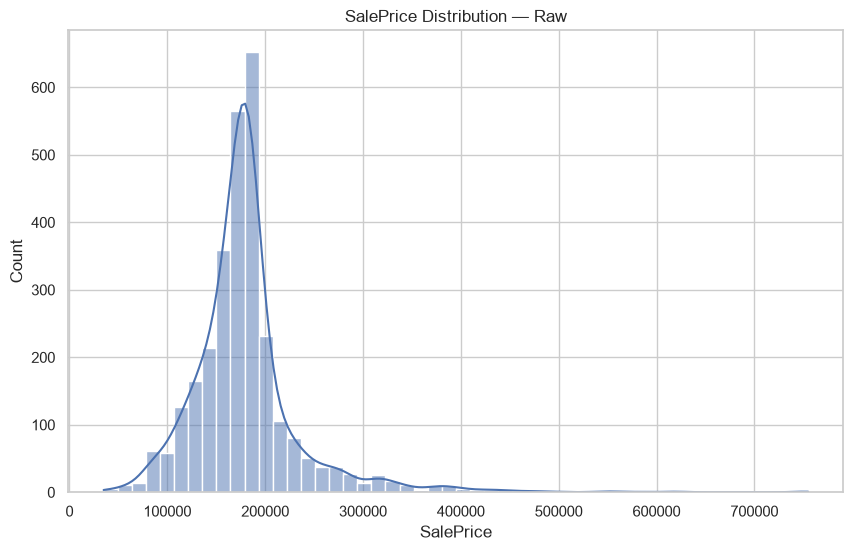


Skewness (raw SalePrice): 2.549


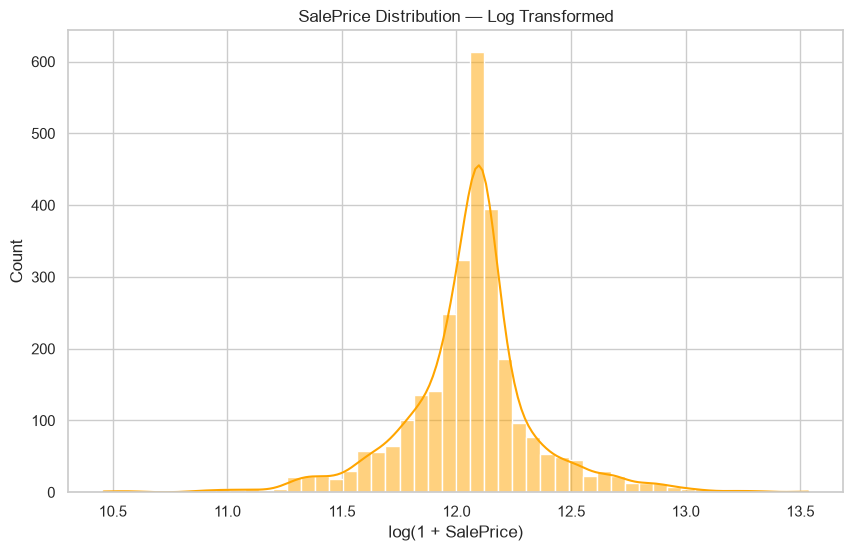

Skewness (log SalePrice): -0.150

→ Raw skewness: 2.549  →  Log skewness: -0.150
→ Log transform successfully normalized the distribution.

DataFrame now has 71 columns (added LogSalePrice)


In [3]:
import sys
sys.path.insert(0, r'C:\Users\ycode\Documents\Ames-Housing-ML\src')

from src.analysis import analyze_target

df = analyze_target(df, 'SalePrice')

print(f'\nDataFrame now has {len(df.columns)} columns (added LogSalePrice)')

---
## 4. Correlation with Target — Numeric Features

Pearson correlation of all numeric columns with SalePrice and LogSalePrice. Identify strongest predictors.

  CORRELATIONS WITH SALEPRICE (RAW)
=== Correlations with SalePrice ===

Top 15 positive correlations:
SalePrice       1.000000
LogSalePrice    0.942008
GrLivArea       0.588010
OverallQual     0.550911
TotRmsAbvGrd    0.469800
GarageCars      0.469249
GarageArea      0.464809
1stFlrSF        0.462865
TotalBsmtSF     0.453089
FullBath        0.433710
YearBuilt       0.362066
Fireplaces      0.353567
MasVnrArea      0.351883
YearRemodAdd    0.350032
HasFireplace    0.349652

Top 15 negative correlations:
GarageYrBlt      0.184387
BsmtUnfSF        0.175312
HasGarage        0.168865
BsmtFullBath     0.147705
HasBasement      0.097403
ScreenPorch      0.082308
PoolArea         0.081039
MoSold           0.067222
3SsnPorch        0.029979
Id              -0.011630
BsmtHalfBath    -0.012623
YrSold          -0.039064
OverallCond     -0.065785
EnclosedPorch   -0.070698
MSSubClass      -0.087910

Features with |correlation| < 0.1: 11 (likely not individually predictive)


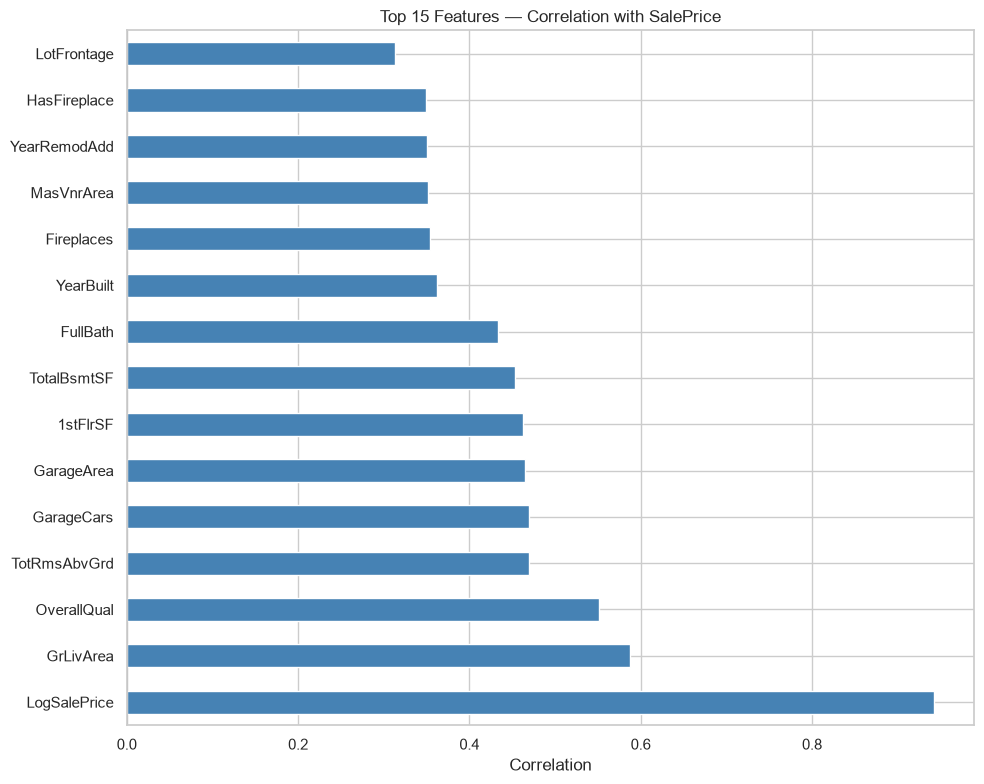


  CORRELATIONS WITH LOGSALEPRICE
=== Correlations with LogSalePrice ===

Top 15 positive correlations:
LogSalePrice    1.000000
SalePrice       0.942008
GrLivArea       0.578486
OverallQual     0.563275
GarageCars      0.494292
GarageArea      0.481480
TotRmsAbvGrd    0.468042
FullBath        0.457031
1stFlrSF        0.453791
TotalBsmtSF     0.448106
YearBuilt       0.402435
YearRemodAdd    0.382440
HasFireplace    0.370299
Fireplaces      0.364122
MasVnrArea      0.316480

Top 15 negative correlations:
OpenPorchSF      0.240089
HasGarage        0.228648
BsmtUnfSF        0.178556
BsmtFullBath     0.152059
HasBasement      0.127090
Id               0.104729
ScreenPorch      0.090505
MoSold           0.072251
PoolArea         0.061034
3SsnPorch        0.032962
BsmtHalfBath    -0.002636
OverallCond     -0.038253
YrSold          -0.048670
EnclosedPorch   -0.079902
MSSubClass      -0.085189

Features with |correlation| < 0.1: 9 (likely not individually predictive)


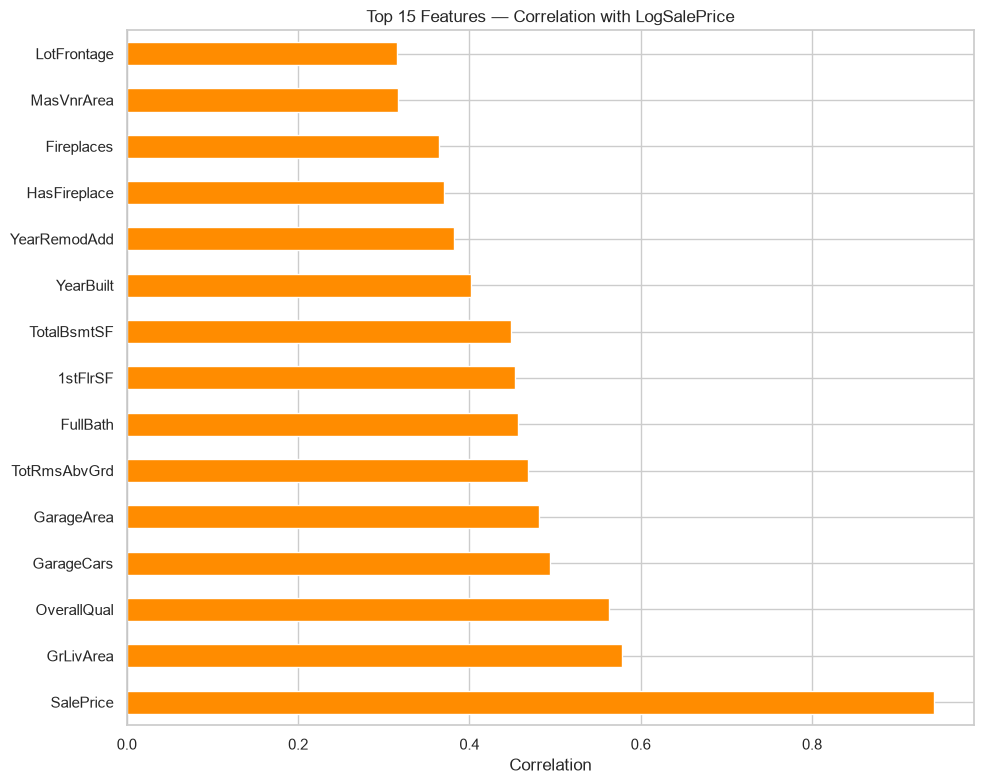

In [4]:
from src.analysis import analyze_correlations

print('=' * 60)
print('  CORRELATIONS WITH SALEPRICE (RAW)')
print('=' * 60)
corr_sale = analyze_correlations(df, 'SalePrice', top_n=15, plot=True)

print('\n' + '=' * 60)
print('  CORRELATIONS WITH LOGSALEPRICE')
print('=' * 60)
corr_log = analyze_correlations(df, 'LogSalePrice', top_n=15, plot=False)

# Also show the bar chart for LogSalePrice
plt.figure(figsize=(10, 8))
corr_log.head(16).drop('LogSalePrice', errors='ignore').plot(
    kind='barh', color='darkorange'
)
plt.title('Top 15 Features — Correlation with LogSalePrice')
plt.xlabel('Correlation')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. Categorical Features — Low Cardinality

For categorical columns with ≤ 15 unique values, show mean/median/count/std of SalePrice by category.

In [5]:
from src.analysis import analyze_categoricals_low_card

analyze_categoricals_low_card(df, max_unique=15, target='SalePrice')

=== Categorical Columns — Low Cardinality (<= 15 unique) ===
Found 31 columns: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

  MSZoning  (5 unique values)
                   mean         median  count           std
MSZoning                                                   
FV        189230.398290  176477.026606    139  43811.245783
RL        186532.179832  179900.000000   2265  58744.792145
RM        149512.759754  155179.708954    460  41690.513520
RH        146854.972509  158115.127713     26  35181.861086
C (all)   133257.122150  159695.999764     25  54013.416051

  Street  (2 unique values)
               

---
## 6. Categorical Features — High Cardinality

Categorical columns with > 15 unique values. Check value distributions and Neighborhood deep dive.

=== Categorical Columns — High Cardinality (> 15 unique) ===
Found 2 columns: ['Neighborhood', 'Exterior2nd']

  Neighborhood  (25 unique values)
Top 10 most frequent values:
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125

  Exterior2nd  (16 unique values)
Top 10 most frequent values:
Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38

  Neighborhood — Mean SalePrice (sorted)
                       mean         median  count
Neighborhood                                     
NoRidge       275074.860533  258000.000000     71
StoneBr       245141.360470  207500.000000     51
NridgHt       243751.175245  200685.038665    166
Timber        214270.893727  188039.055683     72
Veenker       208532.115596  187111.326632     24
ClearCr       201841.549164  19002

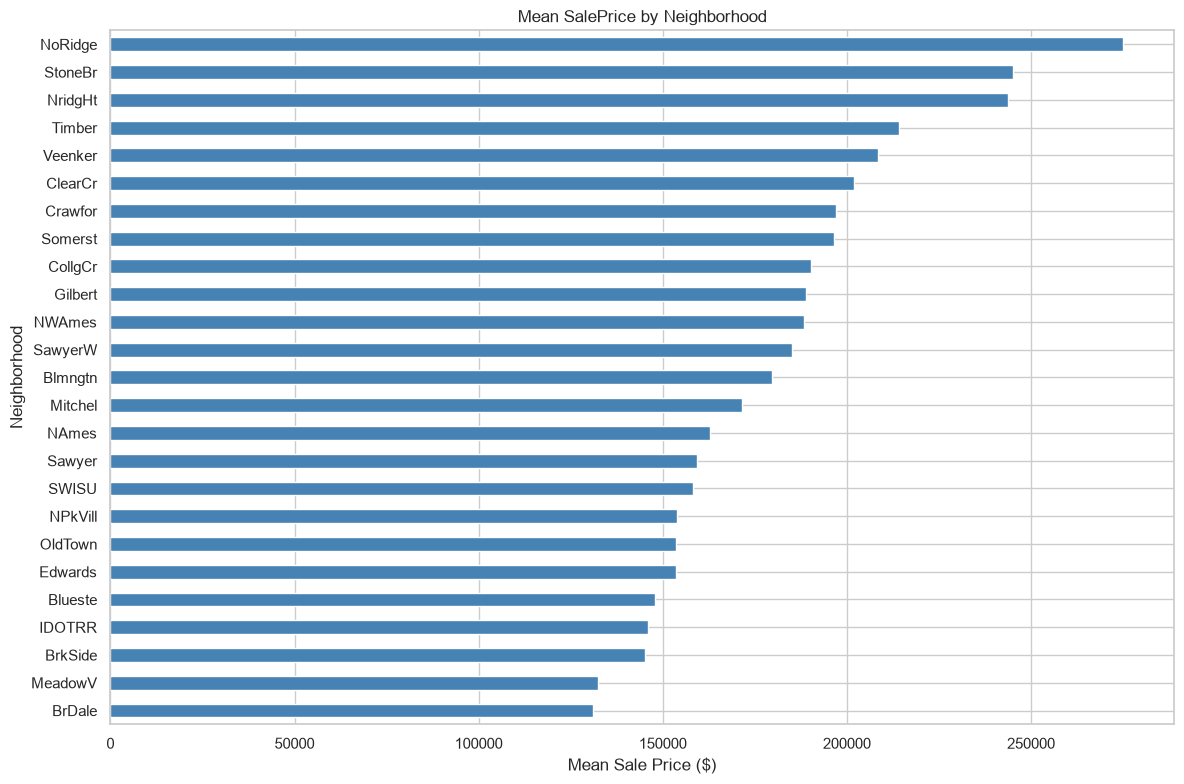

In [6]:
from src.analysis import analyze_categoricals_high_card

analyze_categoricals_high_card(df, target='SalePrice')

---
## 7. Outlier Detection — Target Variable

Two methods:
- Z-score on LogSalePrice (> 3σ — catches extreme outliers)
- IQR on raw SalePrice (catches more, including expensive houses that may not be errors)

Compare results.

In [7]:
from src.analysis import detect_target_outliers

outliers = detect_target_outliers(df, target='SalePrice', log_target='LogSalePrice')

# Summary
print('=' * 60)
print('  OUTLIER SUMMARY')
print('=' * 60)
print(f'Z-score outliers (LogSalePrice, >3σ): {len(outliers["zscore"])} houses')
print(f'IQR outliers (SalePrice): {len(outliers["iqr"])} houses')
print()
print('Note: Z-score on log catches FEWER but MORE EXTREME outliers.')
print('IQR on raw catches more including expensive-but-legitimate houses.')
print('Decide which to act on based on whether they look like data errors.')

=== Outliers by Z-score on LogSalePrice (> 3σ) ===
Count: 45
      SalePrice  GrLivArea  OverallQual  YearBuilt Neighborhood HouseStyle
29      68500.0        520            4       1927      BrkSide     1Story
30      40000.0       1317            4       1920       IDOTRR     2Story
58     438780.0       2945           10       2006      StoneBr     2Story
178    501837.0       2234            9       2008      StoneBr     1Story
185    475000.0       3608           10       1892      OldTown     2.5Fin
278    415298.0       2121            9       2006      NridgHt     1Story
349    437154.0       2728            9       2005      NridgHt     2Story
375     61000.0        904            1       1922      Edwards     1Story
389    426000.0       2332           10       2007      NridgHt     2Story
398     67000.0       1077            5       1920       IDOTRR     1Story
410     60000.0       1276            5       1958      Edwards     1Story
440    555000.0       2402           10

---
## 8. Outlier Detection — Feature Scatter Plots

Visual inspection of key features vs SalePrice. The most important: GrLivArea vs SalePrice
(shows the classic outlier pattern — large houses with low prices).

Also: LotArea, TotalBsmtSF, GarageArea, MasVnrArea, and more.

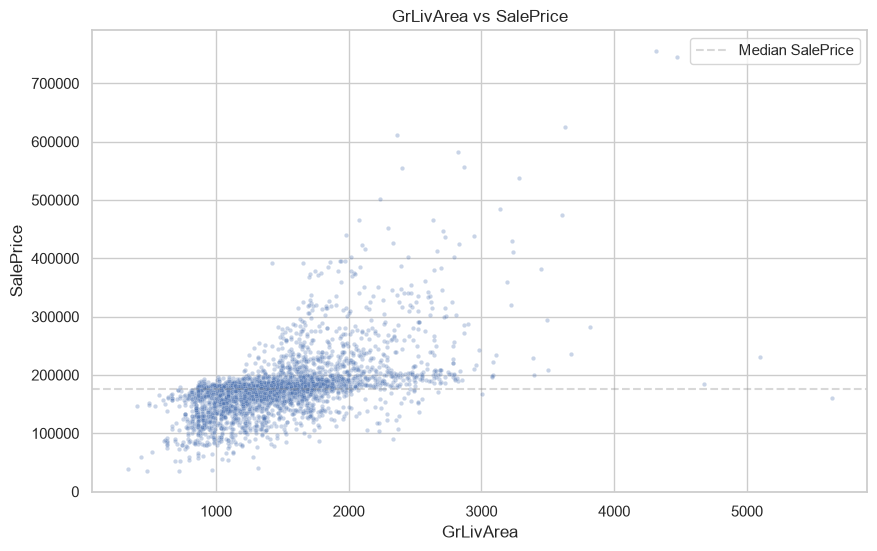

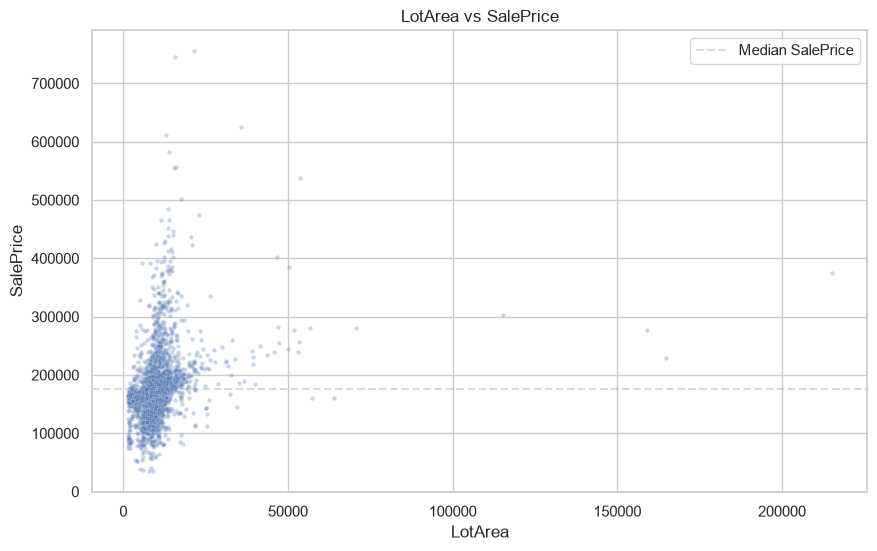

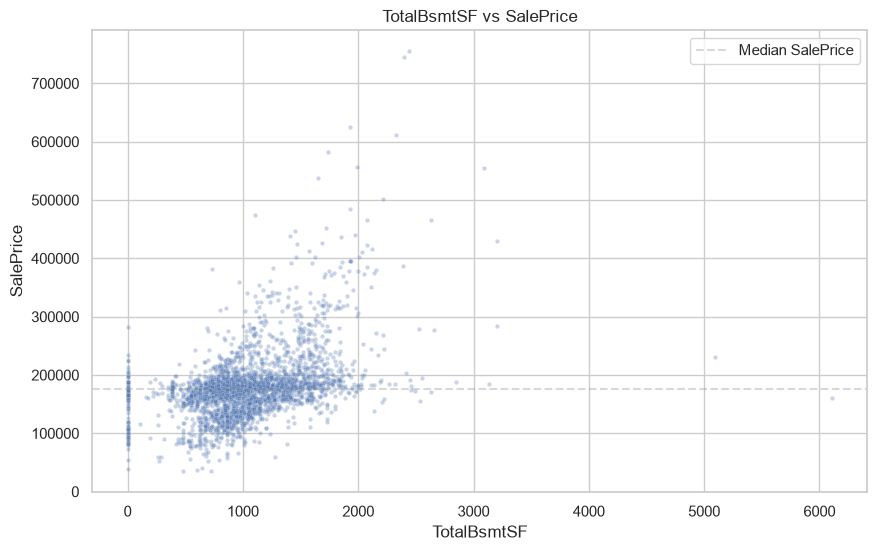

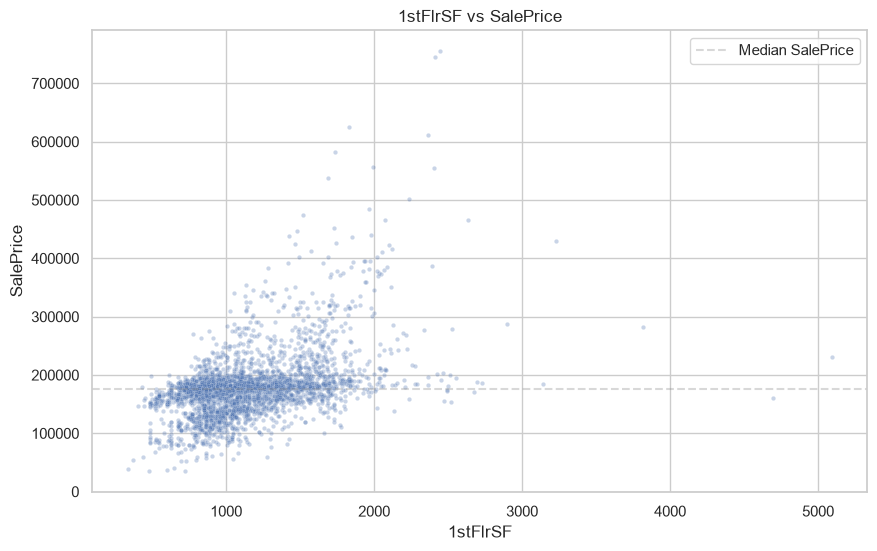

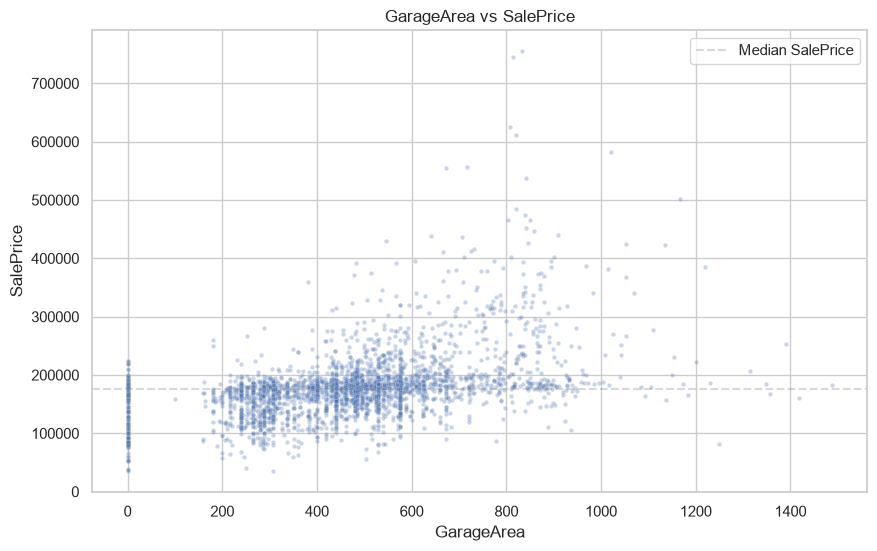

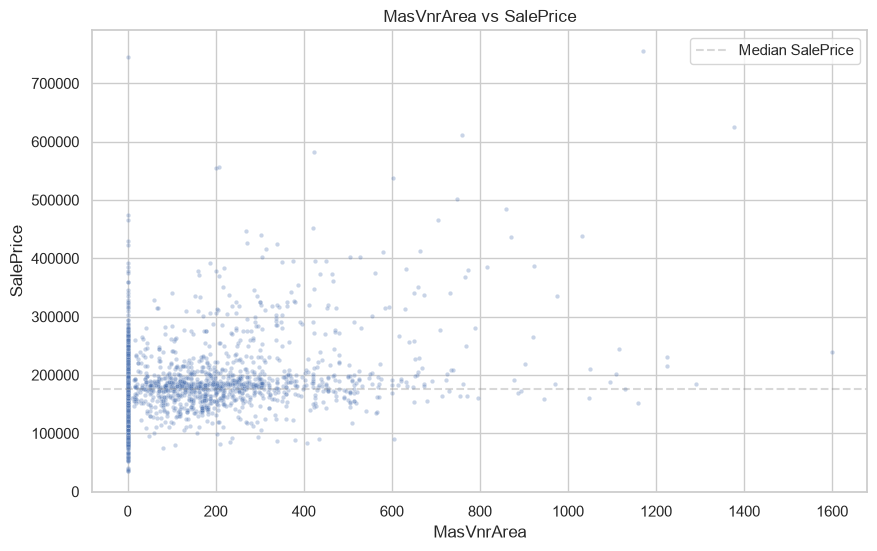

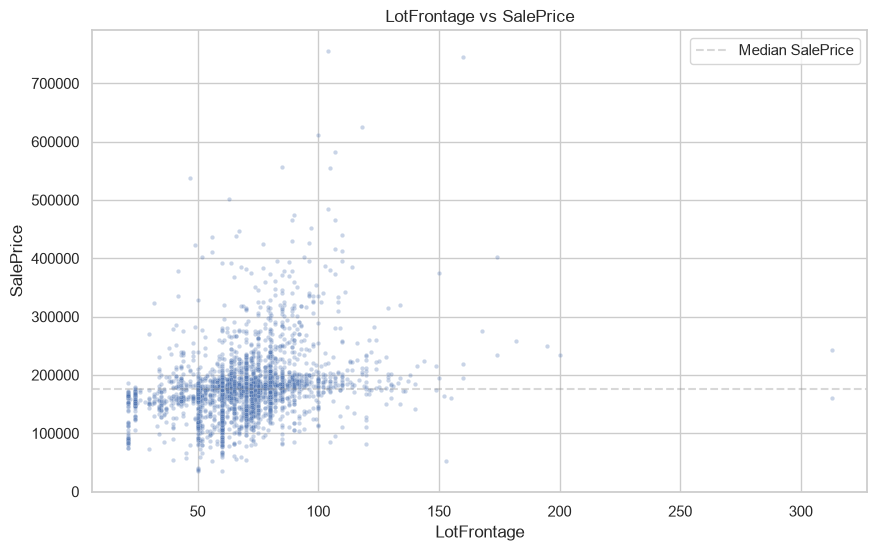

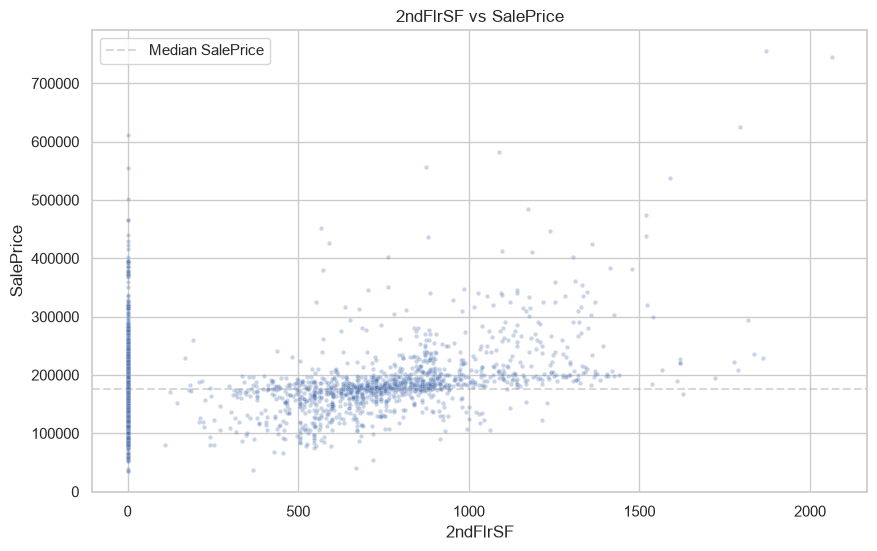

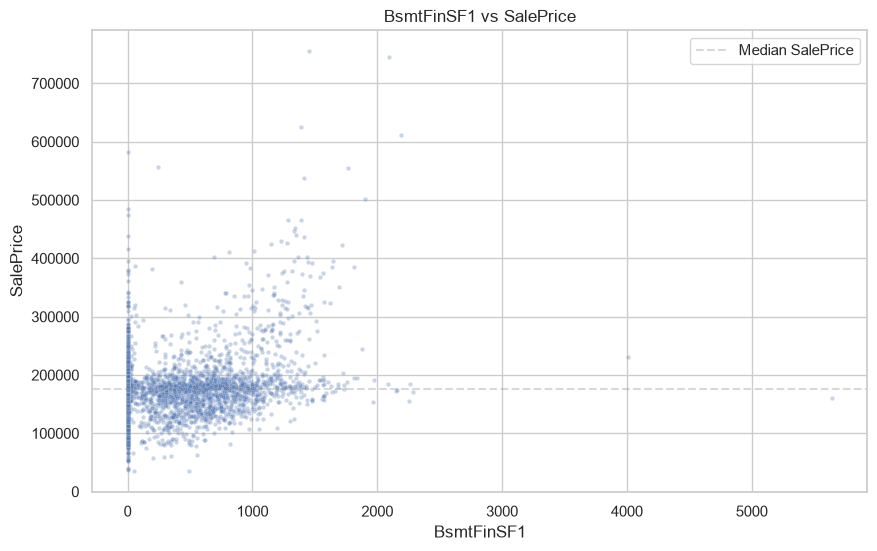


=== GrLivArea Outlier Candidates ===
GrLivArea > 3500 sqft AND SalePrice < $300K
Count: 5
          SalePrice  GrLivArea  OverallQual  YearBuilt Neighborhood HouseStyle    Id
523   184750.000000       4676           10       2007      Edwards     2Story   524
1298  160000.000000       5642           10       2008      Edwards     2Story  1299
2188  281643.976117       3820            5       1959      Edwards     1Story  2189
2549  230841.338626       5095           10       2008      Edwards     1Story  2550
2822  235419.373449       3672            6       1935      Edwards     2.5Unf  2823

Check the plots above. The GrLivArea vs SalePrice plot is the key one.
Look for points in the top-left region: large area, low price.
Those are the candidate outliers to examine.


In [8]:
from src.analysis import plot_feature_scatter_outliers

plot_feature_scatter_outliers(df, target='SalePrice')

print('\nCheck the plots above. The GrLivArea vs SalePrice plot is the key one.')
print('Look for points in the top-left region: large area, low price.')
print('Those are the candidate outliers to examine.')

---
## 9. Outlier Detection — Additional Features

Check other features for extreme values: LotFrontage, 1stFlrSF, 2ndFlrSF, BsmtFinSF1, WoodDeckSF, OpenPorchSF, PoolArea.

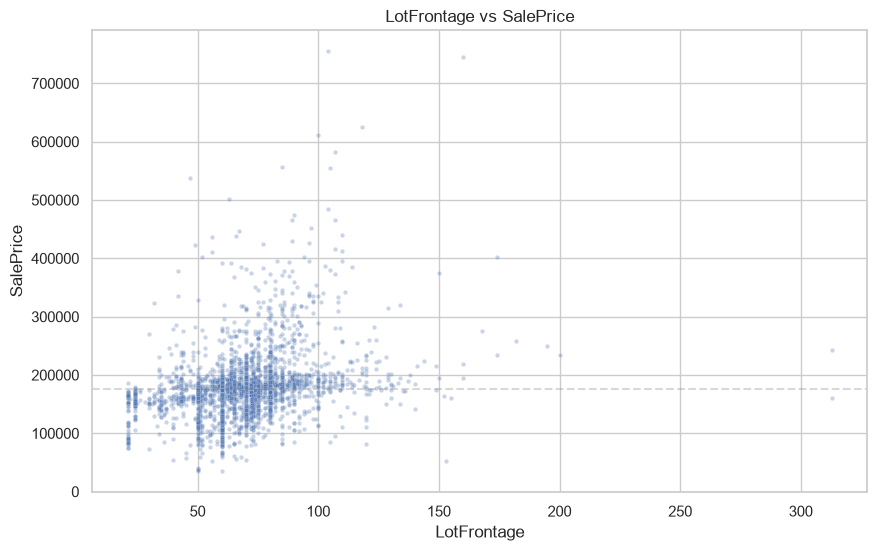

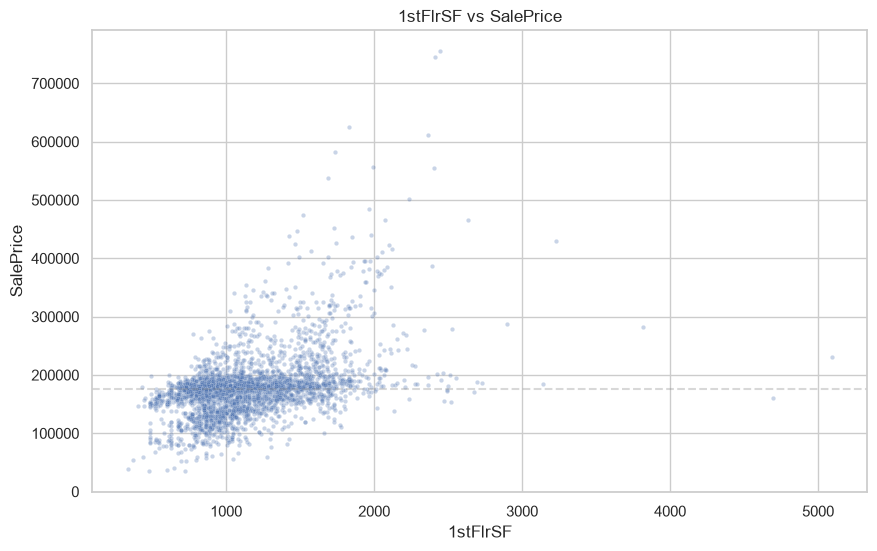

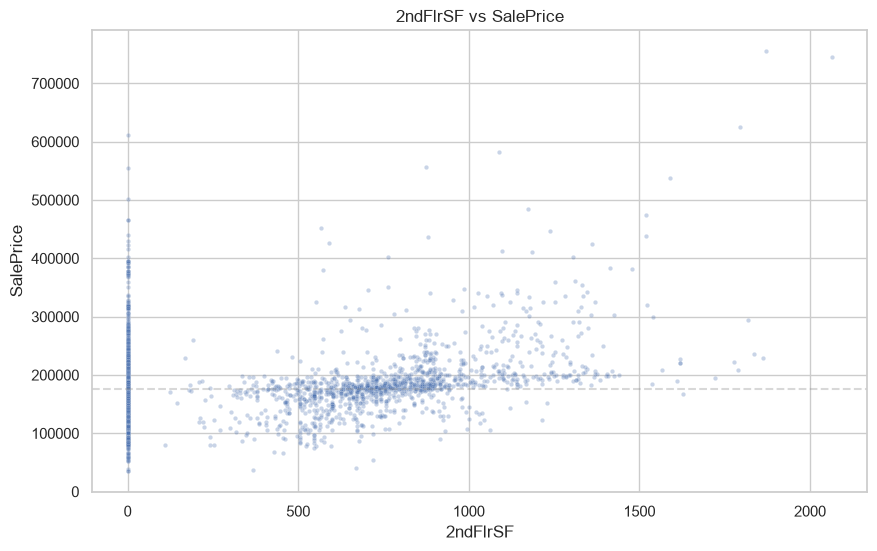

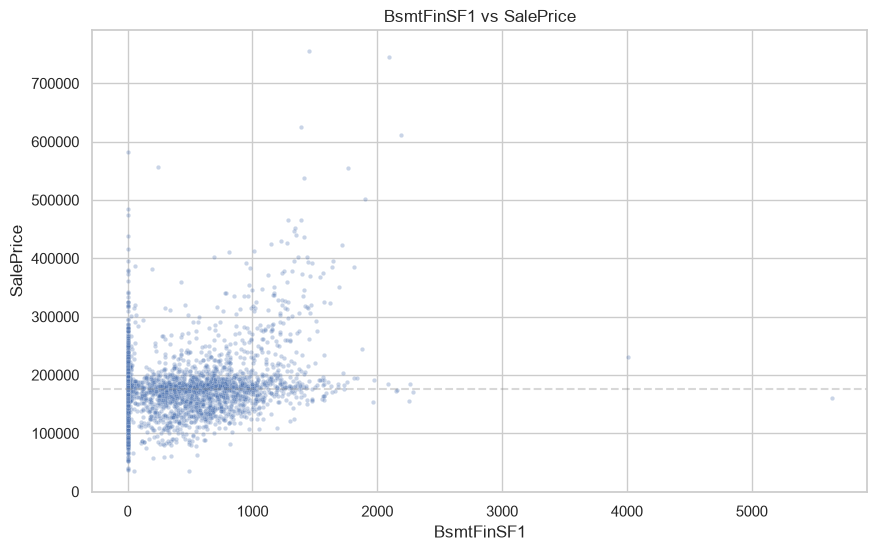

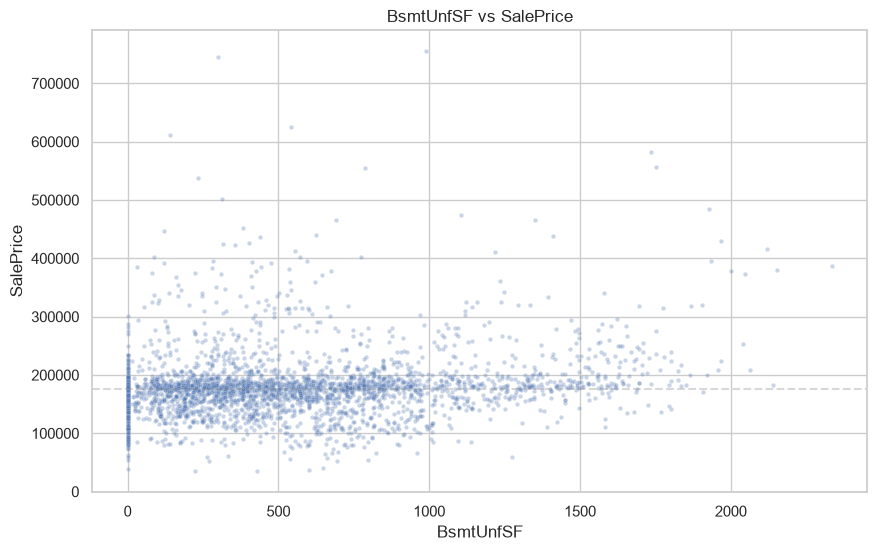

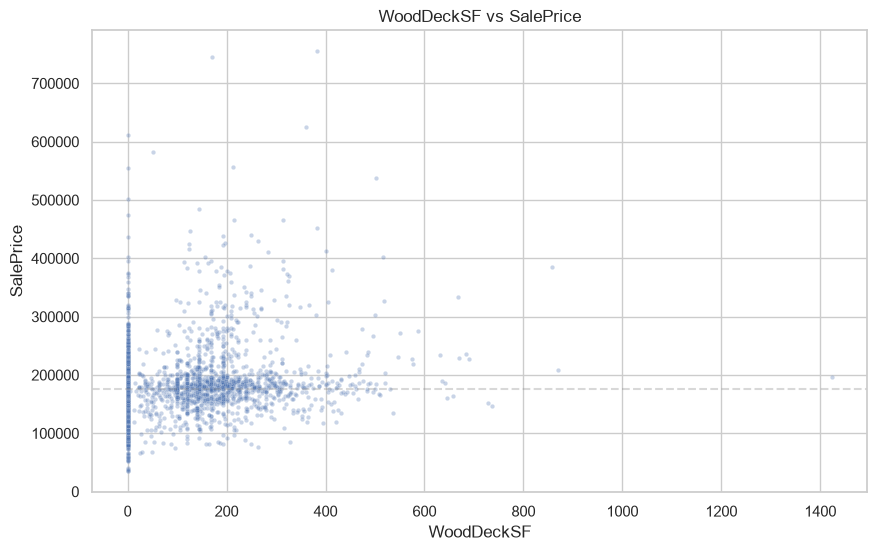

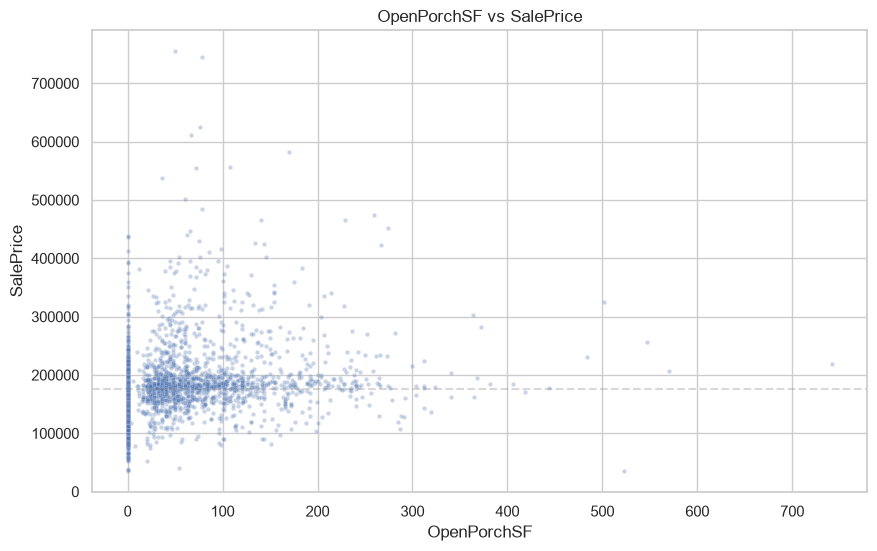

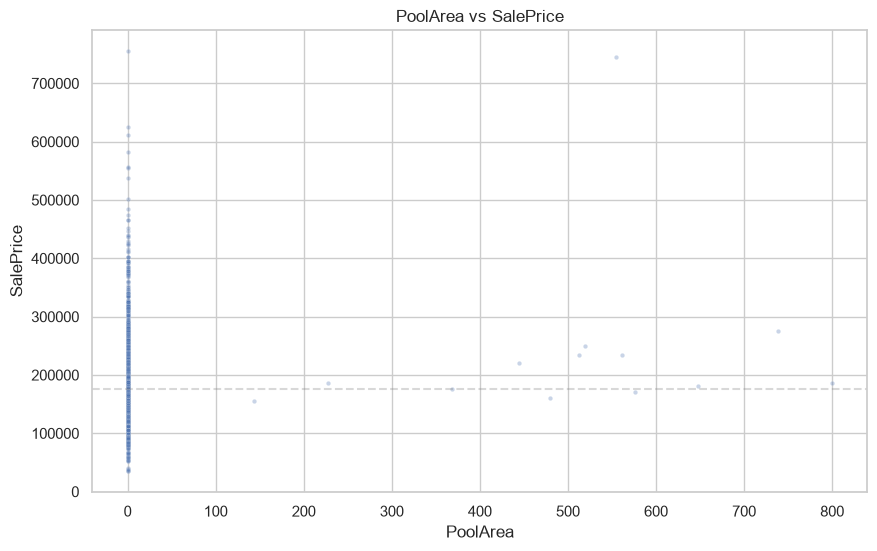

In [9]:
from src.analysis import plot_additional_feature_scatter

plot_additional_feature_scatter(df, target='SalePrice')

---
## 10. Outlier Decision Summary

Document your findings and decisions for each outlier group.

For each: what did you find? How many? Is it a data error or a real but unusual property?
What's your decision: remove, cap, keep and rely on log transform, or keep for tree models?

In [10]:
# Fill this in after reviewing all plots and statistics above.
# This is your analysis summary — update with your actual findings.

outlier_decisions = [
    {
        'Feature': 'SalePrice',
        'Issue': 'Right-skewed distribution (skew=2.549), long right tail',
        'Decision': 'Log transform for Linear Regression models',
        'Action': 'df["LogSalePrice"] = np.log1p(df["SalePrice"]) — already done in Section 3'
    },
    {
        'Feature': 'GrLivArea',
        'Issue': 'Houses with area > 3500-4000 sqft and low price < $300K',
        'Decision': 'REVIEW — likely data errors or unusual properties',
        'Action': 'Check IDs in Section 8 output. Remove if confirmed errors.'
    },
    {
        'Feature': 'LotArea',
        'Issue': 'A few houses with LotArea > 100000 sqft — extreme but may be valid',
        'Decision': 'Keep — tree models handle outliers; Linear Regression may need capping',
        'Action': 'Monitor during modeling; consider capping if Linear Regression underperforms'
    },
    {
        'Feature': 'LogSalePrice',
        'Issue': 'Distribution now near-symmetric (skew approx -0.150)',
        'Decision': 'Use for Linear Regression; raw SalePrice for tree models',
        'Action': 'Both targets available in DataFrame'
    },
]

# Convert to DataFrame and display
import pandas as pd
decisions_df = pd.DataFrame(outlier_decisions)
print('=== Outlier Decision Summary ===')
print(decisions_df.to_string(index=False))

=== Outlier Decision Summary ===
     Feature                                                              Issue                                                               Decision                                                                       Action
   SalePrice            Right-skewed distribution (skew=2.549), long right tail                             Log transform for Linear Regression models   df["LogSalePrice"] = np.log1p(df["SalePrice"]) — already done in Section 3
   GrLivArea            Houses with area > 3500-4000 sqft and low price < $300K                      REVIEW — likely data errors or unusual properties                   Check IDs in Section 8 output. Remove if confirmed errors.
     LotArea A few houses with LotArea > 100000 sqft — extreme but may be valid Keep — tree models handle outliers; Linear Regression may need capping Monitor during modeling; consider capping if Linear Regression underperforms
LogSalePrice               Distribution now near-symmet

---
## 11. Feature Ideas from EDA

List the new features you want to create based on what you observed.

Common Ames features: TotalSF, Age, RemodAge, TotalBath, TotalPorchSF, IsNew.
Also consider: interaction features (OverallQual × GrLivArea), ratio features (GarageCars / GarageArea), and other binaries.

In [11]:
# Fill this in based on your EDA observations.
# Update with features you actually want to create.

feature_ideas = [
    {
        'name': 'TotalSF',
        'formula': 'TotalBsmtSF + 1stFlrSF + 2ndFlrSF',
        'reason': 'Total living space — captures overall house size better than any single floor'
    },
    {
        'name': 'Age',
        'formula': '2025 - YearBuilt',
        'reason': 'Age of the house at time of sale — older houses may need more work'
    },
    {
        'name': 'RemodAge',
        'formula': '2025 - YearRemodAdd',
        'reason': 'Years since last remodel — recent remodels add value'
    },
    {
        'name': 'TotalBath',
        'formula': 'FullBath + 0.5 * HalfBath + BsmtFullBath + 0.5 * BsmtHalfBath',
        'reason': 'Total bathroom count weighted by type (half-baths count as 0.5)'
    },
    {
        'name': 'TotalPorchSF',
        'formula': 'OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch',
        'reason': 'Total outdoor living space across all porch types'
    },
    {
        'name': 'IsNew',
        'formula': '(YearBuilt == YrSold).astype(int)',
        'reason': 'Brand new construction — premium for never-lived-in homes'
    },
]

print('=== Feature Ideas ===')
print(f'Total ideas: {len(feature_ideas)}\n')
for i, idea in enumerate(feature_ideas, 1):
    print(f'{i}. {idea["name"]}')
    print(f'   Formula: {idea["formula"]}')
    print(f'   Reason: {idea["reason"]}')
    print()

=== Feature Ideas ===
Total ideas: 6

1. TotalSF
   Formula: TotalBsmtSF + 1stFlrSF + 2ndFlrSF
   Reason: Total living space — captures overall house size better than any single floor

2. Age
   Formula: 2025 - YearBuilt
   Reason: Age of the house at time of sale — older houses may need more work

3. RemodAge
   Formula: 2025 - YearRemodAdd
   Reason: Years since last remodel — recent remodels add value

4. TotalBath
   Formula: FullBath + 0.5 * HalfBath + BsmtFullBath + 0.5 * BsmtHalfBath
   Reason: Total bathroom count weighted by type (half-baths count as 0.5)

5. TotalPorchSF
   Formula: OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
   Reason: Total outdoor living space across all porch types

6. IsNew
   Formula: (YearBuilt == YrSold).astype(int)
   Reason: Brand new construction — premium for never-lived-in homes



---
## 12. Final Data Check

Confirm the cleaned data is ready for feature engineering.

- Shape: should be (2919, ~65) after CleanData adds binary features
- No missing values
- Column list: confirm the 19 dropped columns are gone, binary features added

In [ ]:
from src.analysis import final_data_check

shape, missing_count, columns = final_data_check(df)


print(f'Shape: {shape[0]} rows × {shape[1]} columns')
print(f'Missing values: {missing_count} columns')
print(f'Binary features added: HasGarage, HasBasement, HasFireplace')
print(f'LogSalePrice column added: for Linear Regression target')
print()
print('If missing_count == 0: DATA IS CLEAN — ready for feature engineering (Day 2)')

=== Final Data Check ===
Shape: (2919, 71)
Rows: 2919  |  Columns: 71

Missing values: 8 columns with missing data
MSZoning        4
BsmtHalfBath    2
Exterior1st     1
Exterior2nd     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1

Column types:
  Numeric: 38
  Categorical: 33

All columns (71):
    1. Id
    2. MSSubClass
    3. MSZoning
    4. LotFrontage
    5. LotArea
    6. Street
    7. LotShape
    8. LandContour
    9. Neighborhood
   10. Condition1
   11. BldgType
   12. HouseStyle
   13. OverallQual
   14. OverallCond
   15. YearBuilt
   16. YearRemodAdd
   17. RoofStyle
   18. Exterior1st
   19. Exterior2nd
   20. MasVnrType
   21. MasVnrArea
   22. ExterQual
   23. ExterCond
   24. Foundation
   25. BsmtQual
   26. BsmtCond
   27. BsmtExposure
   28. BsmtFinType1
   29. BsmtFinSF1
   30. BsmtFinType2
   31. BsmtUnfSF
   32. TotalBsmtSF
   33. Heating
   34. HeatingQC
   35. CentralAir
   36. Electrical
   37. 1stFlrSF
   38. 2ndFlrSF
   39. GrLiv

: 

---
## 13. Next Steps — Day 2 Preview

**Day 2 — Feature Engineering**

1. Create new features from Section 11 (TotalSF, Age, RemodAge, TotalBath, TotalPorchSF, IsNew, etc.)
2. Encode ordinal categoricals as integers
   (OverallQual, ExterQual, KitchenQual, BsmtQual, HeatingQC, FireplaceQu, GarageQual, GarageCond, etc.)
3. One-Hot Encode nominal categoricals
   (Neighborhood, MSZoning, BldgType, HouseStyle, RoofStyle, Exterior1st, SaleType, SaleCondition, CentralAir, PavedDrive, Electrical, Functional, etc.)
4. Verify new feature correlations with SalePrice
5. Check for multicollinearity between new and existing features
6. Final feature set decision

**Day 3 — Modeling**

Split data → build preprocessing pipeline (ColumnTransformer + Pipeline) →
train 3 models (Linear Regression, Random Forest, XGBoost) → evaluate and compare.